# 💬 Pipeline de análisis de sentimiento de los comentarios
### Reto Analítica Educativa · Samsung Innovation Campus · equipo Tech Tailors
**Clasifica el sentimiento de los comentarios con 3 modelos en español + votación por mayoría, y consolida un *gold standard* validado a mano.**

| | |
|---|---|
| Proyecto | Analítica Educativa — evaluaciones docentes |
| Notebook | 02 · Pipeline de sentimiento |
| Objetivo | Etiquetar el sentimiento (POS/NEU/NEG) y exportar los datos procesados |
| Entradas | data/raw/evaluaciones_docentes.csv |
| Salidas | data/processed/evaluaciones_con_sentimiento.csv · gold_standard_comentarios.csv · mapa_sentimiento_comentarios.csv |
| Equipo | Tech Tailors |


In [1]:
# --- Arranque: localizar la raíz del proyecto (para rutas e imports de src/) ---
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'src').is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from src import rutas
print('Raíz del proyecto:', RAIZ)

Raíz del proyecto: /Users/nato/Documents/Analisis de sentimiento


## 0. Instalación de dependencias

Ejecuta esta celda una sola vez. La descarga de los tres modelos puede tardar unos minutos.

In [2]:
%%capture
# Ejecutar una vez. Si ya tienes el entorno, puedes saltarla.
!pip install -q transformers torch sentencepiece protobuf pandas matplotlib seaborn

In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from transformers import pipeline

pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid")

# Paleta consistente por sentimiento
PALETA = {"POS": "#2e7d32", "NEU": "#f9a825", "NEG": "#c62828"}
ORDEN = ["POS", "NEU", "NEG"]

## 1. Cargar y explorar el dataset

In [4]:
RUTA = rutas.datos_raw()
df = pd.read_csv(RUTA)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (3000, 9)


,id_docente,asignatura,semestre,numero_estudiantes,puntaje_claridad,puntaje_metodologia,puntaje_evaluacion,comentario,tendencia_desempeno
0,Docente_41,Matemáticas Básicas,2020-1,38,3.2,4.1,3.9,Cumple con el programa.,Estable
1,Docente_16,Programación Orientada a Objetos,2021-1,38,4.3,3.7,4.1,La clase es muy dinámica y entretenida.,Estable
2,Docente_44,Ingeniería de Software,2020-2,33,4.2,4.2,3.1,Me inspiró a seguir aprendiendo sobre este tema.,Mejora
3,Docente_3,Matemáticas Básicas,2020-2,21,5.0,4.2,4.6,La clase es muy dinámica y entretenida.,Mejora
4,Docente_33,Estructuras de Datos,2020-1,32,4.1,3.7,4.1,La clase es muy dinámica y entretenida.,Mejora


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_docente           3000 non-null   str    
 1   asignatura           3000 non-null   str    
 2   semestre             3000 non-null   str    
 3   numero_estudiantes   3000 non-null   int64  
 4   puntaje_claridad     3000 non-null   float64
 5   puntaje_metodologia  3000 non-null   float64
 6   puntaje_evaluacion   3000 non-null   float64
 7   comentario           3000 non-null   str    
 8   tendencia_desempeno  3000 non-null   str    
dtypes: float64(3), int64(1), str(5)


In [6]:
# Estadística de los puntajes (escala 1-5) y del número de estudiantes
df[["numero_estudiantes", "puntaje_claridad",
    "puntaje_metodologia", "puntaje_evaluacion"]].describe().round(2)

,numero_estudiantes,puntaje_claridad,puntaje_metodologia,puntaje_evaluacion
count,3000.00,3000.00,3000.00,3000.00
mean,29.92,3.73,3.85,3.69
std,8.92,0.86,0.85,0.87
min,15.00,1.00,1.00,1.00
25%,22.00,3.30,3.40,3.20
50%,30.00,3.90,4.00,3.80
75%,38.00,4.30,4.50,4.30
max,45.00,5.00,5.00,5.00


### 1.1 Observaciones clave sobre los datos

In [7]:
print("Comentarios ÚNICOS:", df["comentario"].nunique(), "de", len(df), "filas")
print("Comentarios vacíos:", df["comentario"].isna().sum() + (df["comentario"].str.strip() == "").sum())
print()
print("Distribución de tendencia_desempeno:")
print(df["tendencia_desempeno"].value_counts())
print()
print("Asignaturas:", df["asignatura"].nunique(), "| Semestres:", df["semestre"].nunique())

Comentarios ÚNICOS: 20 de 3000 filas
Comentarios vacíos: 0

Distribución de tendencia_desempeno:
tendencia_desempeno
Estable      1500
Mejora        904
En riesgo     596
Name: count, dtype: int64

Asignaturas: 7 | Semestres: 8


**Dato importante:** solo hay **20 comentarios distintos** repetidos en las 3.000
filas (son plantillas). Por eso clasificamos únicamente esos 20 textos y luego
unimos el resultado a todo el dataset: es exacto y muy eficiente.

In [8]:
# Frecuencia de cada comentario
df["comentario"].value_counts().to_frame("frecuencia")

,frecuencia
comentario,
Los temas son difíciles pero se entienden.,233
La clase estuvo bien.,211
Se podría mejorar un poco el material de estudio.,210
"Asistencia puntual, pero falta dinamismo.",201
"El profesor es normal, ni muy bueno ni muy malo.",180
Cumple con el programa.,179
"Excelente profesor, muy claro.",165
Resuelve las dudas con mucha paciencia.,149
Se nota que sabe mucho de la materia.,145


## 2. Cargar los tres modelos de sentimiento

### 2.0 ¿Cómo fueron entrenados estos modelos? (nota pedagógica)

**Importante:** en este notebook **no entrenamos ningún modelo**. Usamos modelos ya
entrenados por equipos de investigación y publicados en Hugging Face. Esto se llama
***transfer learning* (aprendizaje por transferencia)**: aprovechamos el conocimiento
que el modelo ya adquirió y solo lo aplicamos (inferencia) a nuestros comentarios.

El entrenamiento que hicieron sus autores ocurrió en **dos fases**:

#### Fase 1 — Pre-entrenamiento: aprender el idioma (auto-supervisado)

Al modelo se le muestran millones de textos con palabras ocultas y debe adivinarlas
(*Masked Language Modeling*):

> "El profesor explica muy `[MASK]` los temas" → el modelo aprende que "bien" es probable.

Nadie etiqueta nada a mano: el propio texto es la respuesta correcta (por eso se llama
**auto-supervisado**). Repitiendo esto miles de millones de veces, el modelo aprende
gramática, vocabulario, contexto y hasta ironía básica del español. Es como un
estudiante que lee millones de textos completando espacios en blanco: termina
"sabiendo el idioma", pero todavía no sabe clasificar sentimientos.

- **RoBERTuito**: pre-entrenado con **~500 millones de tuits en español** (equipo pysentimiento).
- **BETO**: pre-entrenado con **~3.000 millones de palabras** de corpus en español —
  Wikipedia, subtítulos, web — (Universidad de Chile, Cañete et al. 2020).
- **XLM-RoBERTa (Twitter)**: pre-entrenado con CommonCrawl en **100 idiomas** y luego
  con **~198 millones de tuits multilingües** (Cardiff NLP, Barbieri et al. 2022).

#### Fase 2 — Fine-tuning: aprender la tarea (supervisado)

Al modelo "que ya sabe español" se le agrega una pequeña **capa clasificadora** de 3
salidas (POS / NEU / NEG) y se le entrena con **ejemplos etiquetados por humanos**:
tuits donde anotadores marcaron el sentimiento. El proceso es el clásico aprendizaje
supervisado:

1. El modelo predice el sentimiento de un tuit etiquetado.
2. Se mide el error contra la etiqueta humana (función de pérdida: *cross-entropy*).
3. Se ajustan los pesos con descenso de gradiente (*backpropagation*).
4. Se repite hasta que clasifica bien ejemplos que nunca vio.

Siguiendo la analogía: el estudiante que ya sabía el idioma toma ahora un curso corto
de "clasificar opiniones" con ejercicios corregidos por un profesor.

- **RoBERTuito y BETO** fueron afinados con el corpus **TASS** (tuits en español
  anotados con POS/NEU/NEG, del taller de la SEPLN).
- **XLM-RoBERTa** fue afinado con tuits anotados en **8 idiomas**, incluido el español.

#### ¿Qué pasa cuando clasificamos un comentario? (inferencia)

```
"Excelente profesor, muy claro."
   │ 1. Tokenización: se parte en sub-palabras y se convierten en números
   │ 2. Embeddings + auto-atención (transformer): cada palabra se interpreta
   │    en su contexto ("claro" junto a "profesor" ≠ "claro" como color)
   │ 3. Capa clasificadora + softmax: probabilidades por clase
   ▼
 { POS: 0.97, NEU: 0.02, NEG: 0.01 }  →  etiqueta: POS
```

#### ¿Por qué esto le sirve a nuestro análisis?

- **No necesitamos datos etiquetados propios**: el conocimiento ya viene en el modelo.
- Los tres fueron afinados con **tuits**: textos cortos e informales, muy parecidos a
  los comentarios de estudiantes — buen ajuste de dominio.
- **Limitación (cambio de dominio):** ninguno vio evaluaciones docentes durante su
  entrenamiento; por eso comparamos **tres modelos con votación por mayoría** en vez
  de confiar en uno solo, y verificamos contra una referencia manual (sección 3.2).


In [9]:
modelo_robertuito = pipeline("sentiment-analysis",
                             model="pysentimiento/robertuito-sentiment-analysis")
modelo_beto = pipeline("sentiment-analysis",
                       model="finiteautomata/beto-sentiment-analysis")
modelo_multilingue = pipeline("sentiment-analysis",
                              model="cardiffnlp/twitter-xlm-roberta-base-sentiment")
print("Modelos cargados.")

Modelos cargados.


### 2.1 Normalización de etiquetas y votación por mayoría

Cada modelo usa nombres distintos (`POS`/`POSITIVE`/`positive`...). Los llevamos a
un esquema común **POS / NEU / NEG**.

Luego combinamos los tres con **votación por mayoría**. Esto corrige el defecto del
notebook original, que elegía el modelo de mayor *confianza* (y por eso a veces
un solo modelo imponía un resultado equivocado). Si los tres discrepan, se usa
`robertuito` como desempate por ser el más específico para español.

In [10]:
MAPA_ETIQUETAS = {
    "POS": "POS", "POSITIVE": "POS", "P": "POS",
    "NEU": "NEU", "NEUTRAL": "NEU",
    "NEG": "NEG", "NEGATIVE": "NEG", "N": "NEG",
}

def normalizar(label):
    return MAPA_ETIQUETAS.get(str(label).upper(), str(label).upper())

def clasificar(texto):
    """Devuelve (etiqueta_final, dict_por_modelo). Mayoría; desempate = robertuito."""
    preds = {
        "robertuito":  normalizar(modelo_robertuito(texto)[0]["label"]),
        "beto":        normalizar(modelo_beto(texto)[0]["label"]),
        "multilingue": normalizar(modelo_multilingue(texto)[0]["label"]),
    }
    conteo = Counter(preds.values())
    etiqueta, votos = conteo.most_common(1)[0]
    if votos == 1:                      # los tres discrepan -> desempate
        etiqueta = preds["robertuito"]
    return etiqueta, preds

## 3. Clasificar los 20 comentarios únicos

In [11]:
registros = []
for c in df["comentario"].unique():
    etiqueta, preds = clasificar(c)
    registros.append({"comentario": c, "sentimiento": etiqueta, **preds})

tabla_sent = pd.DataFrame(registros)
tabla_sent = tabla_sent.sort_values("sentimiento")
tabla_sent.reset_index(drop=True)

,comentario,sentimiento,robertuito,beto,multilingue
0,No resuelve las dudas de los estudiantes.,NEG,NEG,NEU,NEG
1,Falta mucha pedagogía.,NEG,NEG,NEU,NEG
2,Califica de forma injusta.,NEG,NEG,NEG,NEG
3,"No explica bien, me siento perdido.",NEG,NEG,NEG,NEG
4,"Asistencia puntual, pero falta dinamismo.",NEG,NEU,NEG,NEG
5,Llega tarde a las clases frecuentemente.,NEG,NEG,NEG,NEG
6,La clase es muy aburrida y monótona.,NEG,NEG,NEG,NEG
7,Se podría mejorar un poco el material de estudio.,NEU,NEU,NEU,NEU
8,Los temas son difíciles pero se entienden.,NEU,POS,NEU,NEU
9,"El profesor es normal, ni muy bueno ni muy malo.",NEU,NEU,NEU,NEG


### 3.1 Grado de acuerdo entre los tres modelos

In [12]:
def nivel_acuerdo(fila):
    votos = Counter([fila["robertuito"], fila["beto"], fila["multilingue"]])
    return votos.most_common(1)[0][1]  # 3 = unánime, 2 = mayoría, 1 = sin acuerdo

tabla_sent["acuerdo"] = tabla_sent.apply(nivel_acuerdo, axis=1)
print("Comentarios con acuerdo unánime (3/3):", (tabla_sent["acuerdo"] == 3).sum())
print("Con mayoría (2/3):                    ", (tabla_sent["acuerdo"] == 2).sum())
print("Sin acuerdo (1/1/1):                  ", (tabla_sent["acuerdo"] == 1).sum())
tabla_sent[tabla_sent["acuerdo"] < 3][["comentario", "robertuito", "beto",
                                       "multilingue", "sentimiento"]]

Comentarios con acuerdo unánime (3/3): 11
Con mayoría (2/3):                     9
Sin acuerdo (1/1/1):                   0


,comentario,robertuito,beto,multilingue,sentimiento
9,No resuelve las dudas de los estudiantes.,NEG,NEU,NEG,NEG
17,Falta mucha pedagogía.,NEG,NEU,NEG,NEG
18,"Asistencia puntual, pero falta dinamismo.",NEU,NEG,NEG,NEG
10,Los temas son difíciles pero se entienden.,POS,NEU,NEU,NEU
11,"El profesor es normal, ni muy bueno ni muy malo.",NEU,NEU,NEG,NEU
14,Los parciales no tienen nada que ver con lo visto en clase.,NEG,NEU,NEU,NEU
15,Se nota que sabe mucho de la materia.,POS,NEU,NEU,NEU
5,Resuelve las dudas con mucha paciencia.,NEU,POS,NEU,NEU
0,Cumple con el programa.,NEU,POS,NEU,NEU


### 3.2 Verificación contra una referencia manual

Etiquetamos a mano los 20 comentarios (algunos son fronterizos y por eso son subjetivos) para medir qué tan bien acierta la votación.

In [13]:
ESPERADO = {
    # Positivos
    "Excelente profesor, muy claro.": "POS",
    "Resuelve las dudas con mucha paciencia.": "POS",
    "Se nota que sabe mucho de la materia.": "POS",
    "La clase es muy dinámica y entretenida.": "POS",
    "Los talleres son muy útiles para aprender.": "POS",
    "Me inspiró a seguir aprendiendo sobre este tema.": "POS",
    "Explica muy bien los temas.": "POS",
    # Neutros
    "La clase estuvo bien.": "NEU",                      # fronterizo (POS/NEU)
    "El profesor es normal, ni muy bueno ni muy malo.": "NEU",
    "Cumple con el programa.": "NEU",
    "Los temas son difíciles pero se entienden.": "NEU", # mixto
    # Negativos
    "Se podría mejorar un poco el material de estudio.": "NEG",  # fronterizo (NEU/NEG)
    "Asistencia puntual, pero falta dinamismo.": "NEG",         # mixto
    "Califica de forma injusta.": "NEG",
    "La clase es muy aburrida y monótona.": "NEG",
    "Los parciales no tienen nada que ver con lo visto en clase.": "NEG",
    "No explica bien, me siento perdido.": "NEG",
    "Falta mucha pedagogía.": "NEG",
    "No resuelve las dudas de los estudiantes.": "NEG",
    "Llega tarde a las clases frecuentemente.": "NEG",
}

tabla_sent["esperado"] = tabla_sent["comentario"].map(ESPERADO)
tabla_sent["coincide"] = tabla_sent["sentimiento"] == tabla_sent["esperado"]
precision = tabla_sent["coincide"].mean()
print(f"Coincidencia con la referencia manual: {precision:.0%}")
tabla_sent[["comentario", "sentimiento", "esperado", "coincide"]]

Coincidencia con la referencia manual: 75%


,comentario,sentimiento,esperado,coincide
9,No resuelve las dudas de los estudiantes.,NEG,NEG,True
17,Falta mucha pedagogía.,NEG,NEG,True
16,Califica de forma injusta.,NEG,NEG,True
12,"No explica bien, me siento perdido.",NEG,NEG,True
18,"Asistencia puntual, pero falta dinamismo.",NEG,NEG,True
19,Llega tarde a las clases frecuentemente.,NEG,NEG,True
3,La clase es muy aburrida y monótona.,NEG,NEG,True
7,Se podría mejorar un poco el material de estudio.,NEU,NEG,False
10,Los temas son difíciles pero se entienden.,NEU,NEU,True
11,"El profesor es normal, ni muy bueno ni muy malo.",NEU,NEU,True


### 3.3 Unir el sentimiento a las 3.000 filas

In [14]:
mapa = dict(zip(tabla_sent["comentario"], tabla_sent["sentimiento"]))
df["sentimiento"] = df["comentario"].map(mapa)
df["sentimiento"] = pd.Categorical(df["sentimiento"], categories=ORDEN, ordered=True)
df[["comentario", "sentimiento", "tendencia_desempeno"]].head(10)

,comentario,sentimiento,tendencia_desempeno
0,Cumple con el programa.,NEU,Estable
1,La clase es muy dinámica y entretenida.,POS,Estable
2,Me inspiró a seguir aprendiendo sobre este tema.,POS,Mejora
3,La clase es muy dinámica y entretenida.,POS,Mejora
4,La clase es muy dinámica y entretenida.,POS,Mejora
5,La clase es muy aburrida y monótona.,NEG,Estable
6,Los talleres son muy útiles para aprender.,POS,Estable
7,Resuelve las dudas con mucha paciencia.,NEU,Estable
8,"Excelente profesor, muy claro.",POS,Mejora
9,Se podría mejorar un poco el material de estudio.,NEU,Estable


### 3.4 Control de falsos positivos: gold standard manual

Como solo hay **20 comentarios únicos**, la forma más efectiva de eliminar falsos
positivos no es estadística sino directa: **validar a mano las 20 etiquetas** y usar
ese mapa corregido (*gold standard*) sobre las 3.000 filas.

El diccionario `CORRECCIONES` parte del consenso de los modelos y aplica las
correcciones de los casos fronterizos detectados en 3.2. **Es editable**: revisa la
tabla de 3.2 y agrega o quita entradas según tu criterio; el resto del análisis
usará la columna `sentimiento_final`.

In [15]:
# Gold standard: consenso de los modelos + correcciones manuales (editable)
CORRECCIONES = {
    # Falso positivo: elogio tibio, no es un positivo claro
    "La clase estuvo bien.": "NEU",
    # Falsos neutros: son críticas y deben contar como negativas
    "Se podría mejorar un poco el material de estudio.": "NEG",
    "Los parciales no tienen nada que ver con lo visto en clase.": "NEG",
}

gold = tabla_sent[["comentario", "sentimiento"]].rename(
    columns={"sentimiento": "consenso_modelos"}).copy()
gold["etiqueta_final"] = gold["comentario"].map(CORRECCIONES).fillna(gold["consenso_modelos"])

df["sentimiento_final"] = pd.Categorical(
    df["comentario"].map(dict(zip(gold["comentario"], gold["etiqueta_final"]))),
    categories=ORDEN, ordered=True)

print("Comentarios corregidos respecto al consenso de los modelos:")
gold[gold["consenso_modelos"] != gold["etiqueta_final"]]

Comentarios corregidos respecto al consenso de los modelos:


,comentario,consenso_modelos,etiqueta_final
7,Se podría mejorar un poco el material de estudio.,NEU,NEG
14,Los parciales no tienen nada que ver con lo visto en clase.,NEU,NEG
8,La clase estuvo bien.,POS,NEU


In [16]:
# Impacto de la corrección sobre las 3.000 filas
comp = pd.DataFrame({
    "consenso_modelos": df["sentimiento"].value_counts().reindex(ORDEN),
    "gold_standard": df["sentimiento_final"].value_counts().reindex(ORDEN),
})
comp["cambio"] = comp["gold_standard"] - comp["consenso_modelos"]
print(f"Filas que cambiaron de etiqueta: {(df['sentimiento'] != df['sentimiento_final']).sum()} de {len(df)}")
comp

Filas que cambiaron de etiqueta: 545 de 3000


,consenso_modelos,gold_standard,cambio
POS,888,677,-211
NEU,1220,1097,-123
NEG,892,1226,334


### 3.5 Detector de incoherencias: sentimiento vs. puntajes

Red de seguridad automática: un comentario **POS con puntajes bajos** (o **NEG con
puntajes altos**) es sospechoso de estar mal clasificado y merece revisión humana.
Con texto libre real, esta lista sería la cola de revisión manual.

In [17]:
PUNTAJES = ["puntaje_claridad", "puntaje_metodologia", "puntaje_evaluacion"]
df["puntaje_promedio"] = df[PUNTAJES].mean(axis=1)

sospechosos_pos = df[(df["sentimiento_final"] == "POS") & (df["puntaje_promedio"] < 3.0)]
sospechosos_neg = df[(df["sentimiento_final"] == "NEG") & (df["puntaje_promedio"] >= 4.5)]

n_pos = (df["sentimiento_final"] == "POS").sum()
n_neg = (df["sentimiento_final"] == "NEG").sum()
print(f"Posibles falsos POSITIVOS (POS con puntaje < 3.0):  {len(sospechosos_pos):>3} filas ({len(sospechosos_pos)/n_pos:.1%} de los POS)")
print(f"Posibles falsos NEGATIVOS (NEG con puntaje >= 4.5): {len(sospechosos_neg):>3} filas ({len(sospechosos_neg)/n_neg:.1%} de los NEG)")
print()
print("Muestra de posibles falsos positivos:")
sospechosos_pos[["id_docente", "asignatura", "semestre", "comentario",
                 "puntaje_promedio", "sentimiento_final"]].head(10)

Posibles falsos POSITIVOS (POS con puntaje < 3.0):    0 filas (0.0% de los POS)
Posibles falsos NEGATIVOS (NEG con puntaje >= 4.5):  86 filas (7.0% de los NEG)

Muestra de posibles falsos positivos:


,id_docente,asignatura,semestre,comentario,puntaje_promedio,sentimiento_final


In [18]:
print("Muestra de posibles falsos negativos (NEG con puntajes altos):")
sospechosos_neg[["id_docente", "asignatura", "semestre", "comentario",
                 "puntaje_promedio", "sentimiento_final"]].head(10)

Muestra de posibles falsos negativos (NEG con puntajes altos):


,id_docente,asignatura,semestre,comentario,puntaje_promedio,sentimiento_final
32,Docente_28,Programación Orientada a Objetos,2023-2,Se podría mejorar un poco el material de estudio.,4.766667,NEG
63,Docente_19,Programación Orientada a Objetos,2020-1,Se podría mejorar un poco el material de estudio.,4.500000,NEG
88,Docente_3,Bases de Datos,2022-2,"Asistencia puntual, pero falta dinamismo.",4.500000,NEG
144,Docente_21,Bases de Datos,2023-1,"Asistencia puntual, pero falta dinamismo.",4.500000,NEG
150,Docente_43,Matemáticas Básicas,2021-2,Se podría mejorar un poco el material de estudio.,4.900000,NEG
202,Docente_10,Matemáticas Básicas,2020-1,"Asistencia puntual, pero falta dinamismo.",4.800000,NEG
230,Docente_18,Ética Profesional,2023-1,"Asistencia puntual, pero falta dinamismo.",4.733333,NEG
254,Docente_30,Bases de Datos,2020-1,"Asistencia puntual, pero falta dinamismo.",4.566667,NEG
262,Docente_48,Inteligencia Artificial,2022-1,"Asistencia puntual, pero falta dinamismo.",4.766667,NEG
264,Docente_13,Estructuras de Datos,2022-1,"Asistencia puntual, pero falta dinamismo.",4.633333,NEG


## 4. Análisis de resultados

### 4.1 Distribución global del sentimiento

sentimiento
POS     888
NEU    1220
NEG     892
Name: count, dtype: int64

sentimiento
POS    29.6 %
NEU    40.7 %
NEG    29.7 %
Name: count, dtype: str


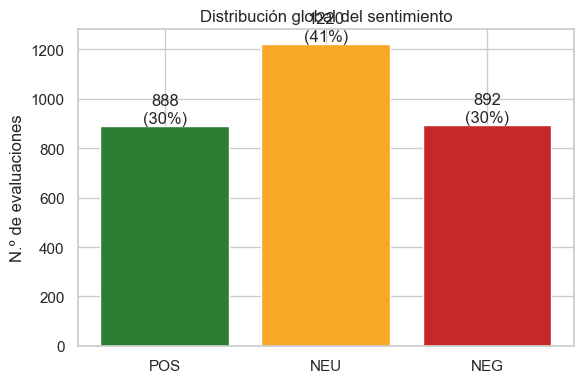

In [19]:
dist = df["sentimiento"].value_counts().reindex(ORDEN)
print(dist)
print()
print((dist / len(df) * 100).round(1).astype(str) + " %")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dist.index, dist.values, color=[PALETA[s] for s in dist.index])
for i, v in enumerate(dist.values):
    ax.text(i, v + 15, f"{v}\n({v/len(df):.0%})", ha="center")
ax.set_title("Distribución global del sentimiento")
ax.set_ylabel("N.º de evaluaciones")
plt.tight_layout(); plt.show()

### 4.2 Sentimiento vs. tendencia de desempeño

¿Los comentarios negativos se concentran en docentes marcados "En riesgo"?

tendencia_desempeno  En riesgo  Estable  Mejora
sentimiento                                    
POS                         55      427     406
NEU                        249      545     426
NEG                        292      528      72


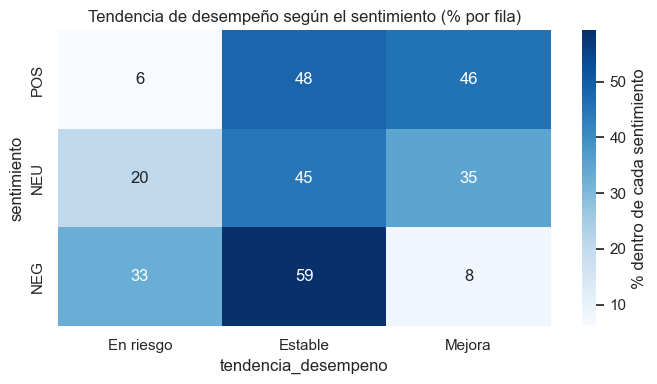

In [20]:
ct = pd.crosstab(df["sentimiento"], df["tendencia_desempeno"])
ct = ct.reindex(index=ORDEN)
print(ct)

ct_pct = pd.crosstab(df["sentimiento"], df["tendencia_desempeno"], normalize="index").reindex(ORDEN)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct_pct * 100, annot=True, fmt=".0f", cmap="Blues", ax=ax,
            cbar_kws={"label": "% dentro de cada sentimiento"})
ax.set_title("Tendencia de desempeño según el sentimiento (% por fila)")
plt.tight_layout(); plt.show()

### 4.3 Sentimiento vs. puntajes numéricos

Validación cruzada: el sentimiento del texto debería alinearse con los puntajes (1–5).

             puntaje_claridad  puntaje_metodologia  puntaje_evaluacion
sentimiento                                                           
POS                      3.99                 4.11                3.97
NEU                      3.75                 3.89                3.70
NEG                      3.43                 3.53                3.39


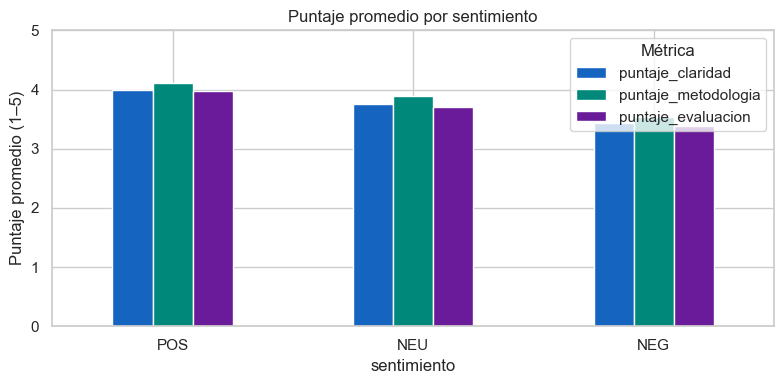

In [21]:
resumen = (df.groupby("sentimiento", observed=True)[["puntaje_claridad",
           "puntaje_metodologia", "puntaje_evaluacion"]].mean().reindex(ORDEN).round(2))
print(resumen)

resumen.plot(kind="bar", figsize=(8, 4), rot=0,
             color=["#1565c0", "#00897b", "#6a1b9a"])
plt.title("Puntaje promedio por sentimiento")
plt.ylabel("Puntaje promedio (1–5)")
plt.ylim(0, 5)
plt.legend(title="Métrica")
plt.tight_layout(); plt.show()

### 4.4 Sentimiento por asignatura

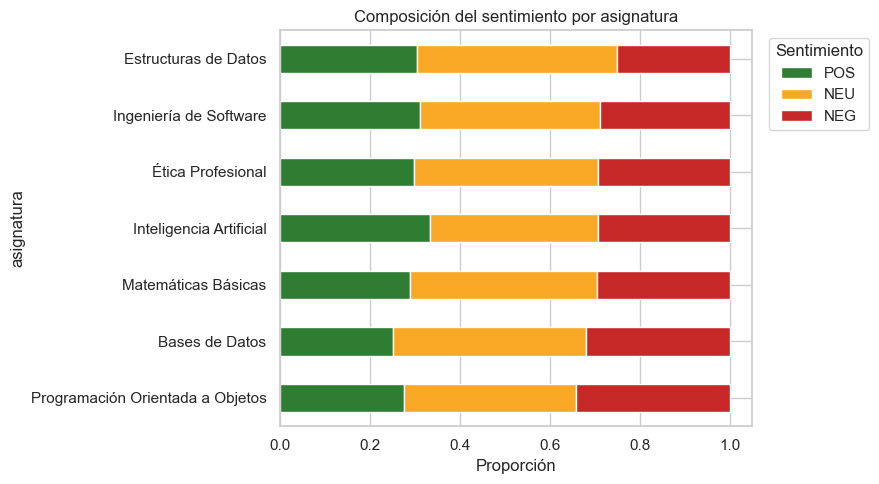

sentimiento,POS,NEU,NEG
asignatura,,,
Programación Orientada a Objetos,27.7,38.1,34.2
Bases de Datos,25.2,42.8,32.0
Matemáticas Básicas,29.0,41.5,29.5
Inteligencia Artificial,33.5,37.4,29.2
Ética Profesional,29.9,41.0,29.2
Ingeniería de Software,31.3,39.9,28.9
Estructuras de Datos,30.6,44.4,25.0


In [22]:
ct_asig = pd.crosstab(df["asignatura"], df["sentimiento"], normalize="index").reindex(columns=ORDEN)
ct_asig = ct_asig.sort_values("NEG", ascending=False)

ct_asig.plot(kind="barh", stacked=True, figsize=(9, 5),
             color=[PALETA[s] for s in ORDEN])
plt.title("Composición del sentimiento por asignatura")
plt.xlabel("Proporción")
plt.legend(title="Sentimiento", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()
(ct_asig * 100).round(1)

### 4.5 Evolución del sentimiento por semestre

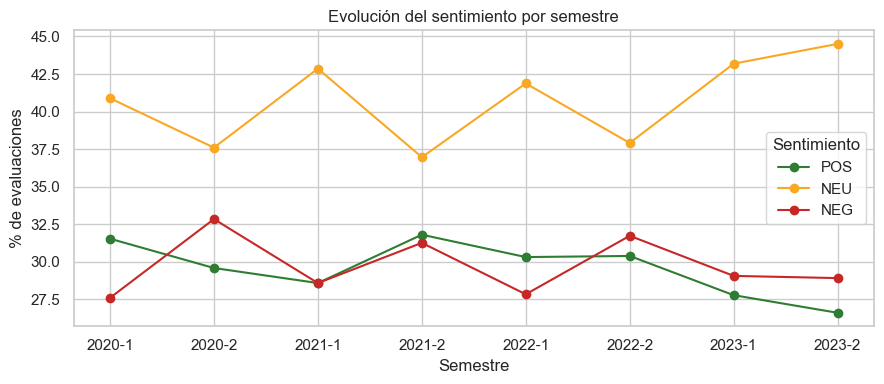

sentimiento,POS,NEU,NEG
semestre,,,
2020-1,31.5,40.9,27.6
2020-2,29.6,37.6,32.8
2021-1,28.6,42.9,28.6
2021-2,31.8,37.0,31.2
2022-1,30.3,41.9,27.8
2022-2,30.4,37.9,31.7
2023-1,27.8,43.2,29.0
2023-2,26.6,44.5,28.9


In [23]:
orden_sem = sorted(df["semestre"].unique())
ct_sem = pd.crosstab(df["semestre"], df["sentimiento"], normalize="index").reindex(orden_sem)[ORDEN]

fig, ax = plt.subplots(figsize=(9, 4))
for s in ORDEN:
    ax.plot(ct_sem.index, ct_sem[s] * 100, marker="o", label=s, color=PALETA[s])
ax.set_title("Evolución del sentimiento por semestre")
ax.set_ylabel("% de evaluaciones")
ax.set_xlabel("Semestre")
ax.legend(title="Sentimiento")
plt.tight_layout(); plt.show()
(ct_sem * 100).round(1)

### 4.6 Docentes con más comentarios negativos

Ranking de docentes por proporción de evaluaciones negativas (mínimo 5 evaluaciones).

In [24]:
por_doc = df.groupby("id_docente")["sentimiento"].agg(
    n="count",
    pct_neg=lambda s: (s == "NEG").mean(),
    pct_pos=lambda s: (s == "POS").mean(),
)
por_doc = por_doc[por_doc["n"] >= 5].sort_values("pct_neg", ascending=False)
por_doc["pct_neg"] = (por_doc["pct_neg"] * 100).round(1)
por_doc["pct_pos"] = (por_doc["pct_pos"] * 100).round(1)
por_doc.head(10)

,n,pct_neg,pct_pos
id_docente,,,
Docente_45,58,43.1,29.3
Docente_4,52,42.3,23.1
Docente_2,48,35.4,14.6
Docente_50,60,35.0,30.0
Docente_33,66,34.8,27.3
Docente_43,69,34.8,27.5
Docente_5,61,34.4,29.5
Docente_3,64,34.4,23.4
Docente_16,47,34.0,34.0


## 5. Exportar resultados

In [25]:
df.to_csv(rutas.datos_processed("evaluaciones_con_sentimiento.csv"), index=False)
tabla_sent.to_csv(rutas.datos_processed("mapa_sentimiento_comentarios.csv"), index=False)
gold.to_csv(rutas.datos_processed("gold_standard_comentarios.csv"), index=False)
print("Guardados:")
print(" - evaluaciones_con_sentimiento.csv   (3.000 filas + sentimiento y sentimiento_final)")
print(" - mapa_sentimiento_comentarios.csv   (los 20 comentarios y su clasificación por modelo)")
print(" - gold_standard_comentarios.csv      (etiquetas definitivas validadas a mano)")

Guardados:
 - evaluaciones_con_sentimiento.csv   (3.000 filas + sentimiento y sentimiento_final)
 - mapa_sentimiento_comentarios.csv   (los 20 comentarios y su clasificación por modelo)
 - gold_standard_comentarios.csv      (etiquetas definitivas validadas a mano)


## 6. Conclusiones

Completa esta sección con los números que arrojen las celdas anteriores. Guía de lectura:

- **Distribución global (4.1):** proporción POS / NEU / NEG en las 3.000 evaluaciones.
- **Sentimiento vs. desempeño (4.2):** si los comentarios NEG concentran la etiqueta
  *En riesgo* y los POS la etiqueta *Mejora*, el texto es coherente con el desempeño.
- **Sentimiento vs. puntajes (4.3):** los puntajes promedio deberían ordenarse
  POS > NEU > NEG. Si no, revisar los comentarios fronterizos de 3.2.
- **Por asignatura y por semestre (4.4–4.5):** dónde y cuándo se concentra lo negativo.

**Limitaciones**
- Los comentarios son 20 plantillas, no texto libre real; el análisis mide el
  sentimiento de esas plantillas, no matices individuales.
- `tendencia_desempeno` no es verdad de terreno del sentimiento; los cruces son
  correlaciones descriptivas, no relaciones causales.
- Casos fronterizos ("La clase estuvo bien", "Se podría mejorar el material")
  admiten más de una etiqueta razonable; ver la verificación de la sección 3.2.
